=== Step 1: system parameters ===
R1=1000.0 ohm, R2=5000.0 ohm, R3=10000.0 ohm, Rp=R2||R3=3333.33 ohm
C1=1.00e-06 F, C2=2.00e-06 F, C3=2.00e-06 F
f0=100.0 Hz, omega=628.3185 rad/s, dt=1.0e-05 s

=== Step 2: K / S decomposition ===
Eigenvalues of dissipative part S: [-1543.4085  -250.5442     0.         0.         0.         0.
     0.       193.9528]
Per-step contraction factors r_i : [0.982776 0.995565 0.998062 0.998062 0.998062 0.998062 0.998062 1.      ]
Classical rescale factor per step g = 1.0019414097
dt*max|eigenvalue of A| = 0.0138 (small -> Strang splitting should be very accurate)

=== Step 3: building one-step quantum circuit ===


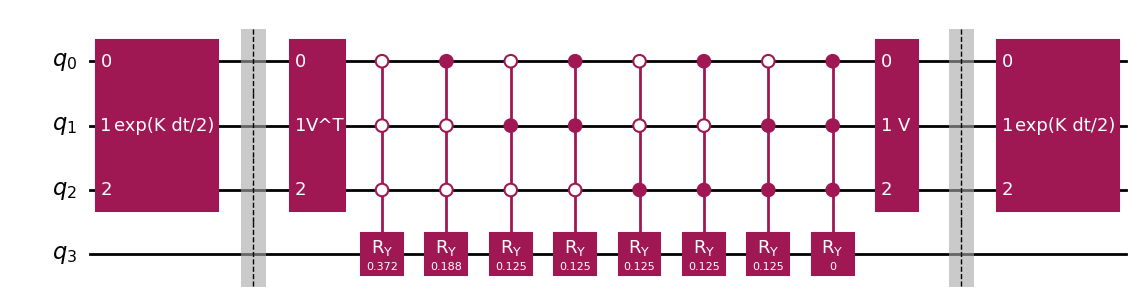


=== Step 4: verifying circuit against exact matrix math ===
||circuit (ancilla=0 block) - exact (K,S)-step||_F = 1.702e-15
Verification SUCCESS: the circuit exactly implements the dilated step.

=== Step 5: running the dilated Trotter evolution ===
Average per-step state fidelity              : 0.999959
Post-selection success probability at t=0.02s : 0.0006


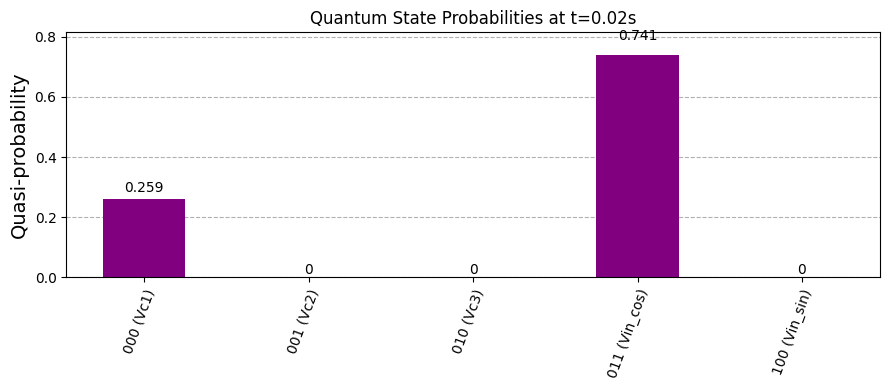


=== Step 7: frequency sweep (Bode plot) ===
f=     1.00 Hz  |  Vc1:  -0.03 dB,   -0.70 deg  |  Vc2:  -6.05 dB,   -1.90 deg  |  Vc3:  -6.05 dB,   -1.90 deg
f=     1.62 Hz  |  Vc1:  -0.46 dB,   -1.77 deg  |  Vc2:  -6.47 dB,   -3.92 deg  |  Vc3:  -6.47 dB,   -3.92 deg
f=     2.64 Hz  |  Vc1:  -0.22 dB,   -0.62 deg  |  Vc2:  -6.27 dB,   -3.92 deg  |  Vc3:  -6.27 dB,   -3.92 deg
f=     4.28 Hz  |  Vc1:  -0.05 dB,   -3.03 deg  |  Vc2:  -6.11 dB,   -8.16 deg  |  Vc3:  -6.11 dB,   -8.16 deg
f=     6.95 Hz  |  Vc1:  -0.10 dB,   -4.88 deg  |  Vc2:  -6.21 dB,  -13.16 deg  |  Vc3:  -6.21 dB,  -13.16 deg
f=    11.29 Hz  |  Vc1:  -0.22 dB,   -7.69 deg  |  Vc2:  -6.48 dB,  -20.99 deg  |  Vc3:  -6.48 dB,  -20.99 deg
f=    18.33 Hz  |  Vc1:  -0.52 dB,  -11.65 deg  |  Vc2:  -7.13 dB,  -32.65 deg  |  Vc3:  -7.13 dB,  -32.65 deg
f=    29.76 Hz  |  Vc1:  -1.07 dB,  -16.42 deg  |  Vc2:  -8.52 dB,  -48.35 deg  |  Vc3:  -8.52 dB,  -48.35 deg
f=    48.33 Hz  |  Vc1:  -1.86 dB,  -21.32 deg  |  Vc2: -10.94 dB, 

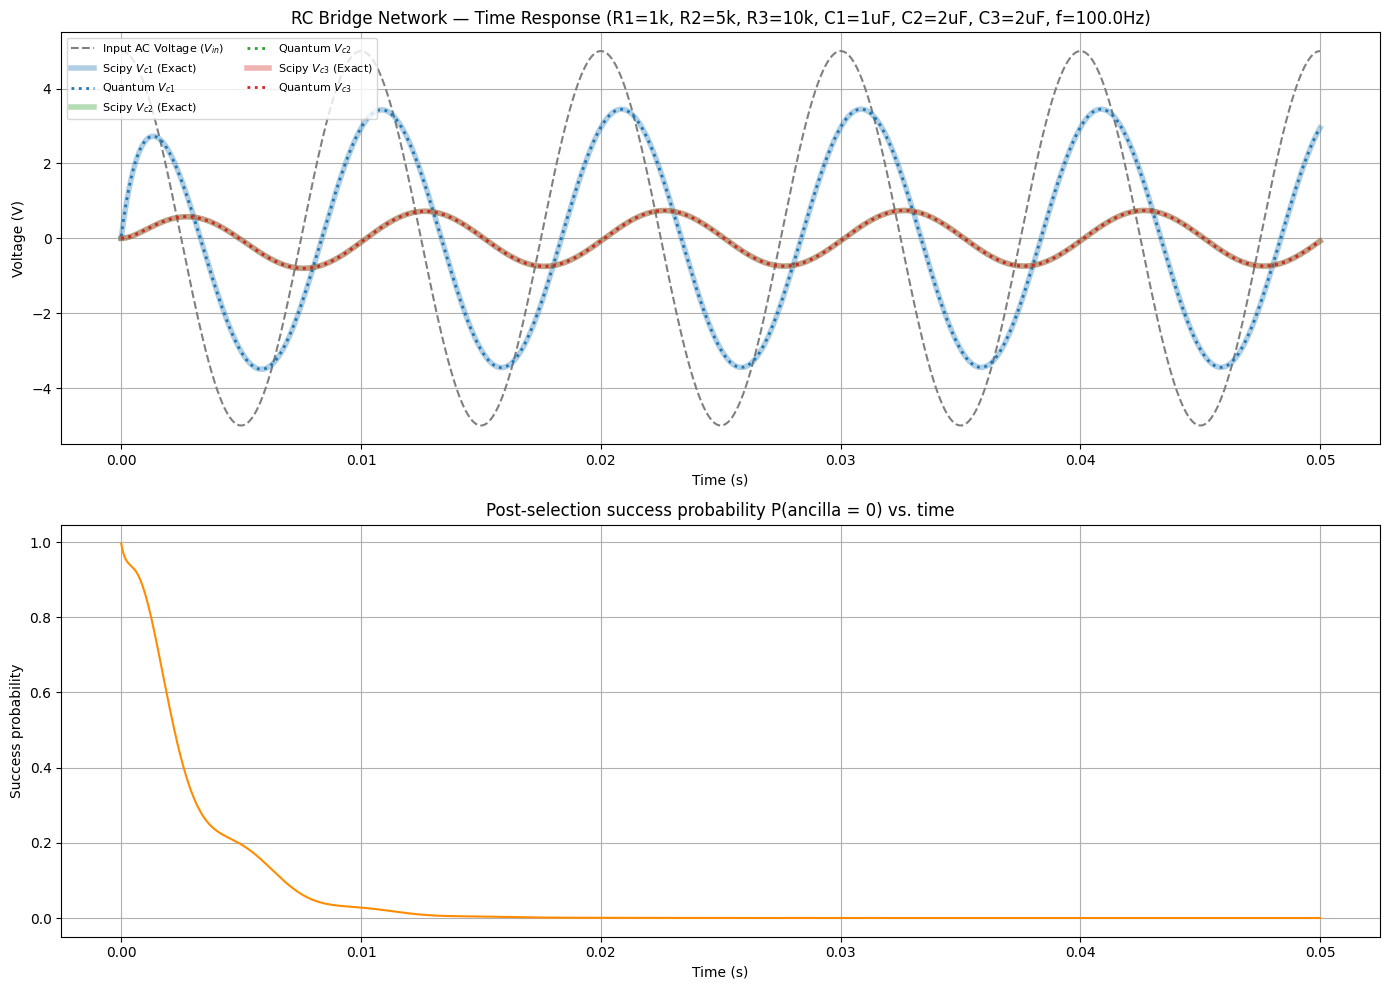

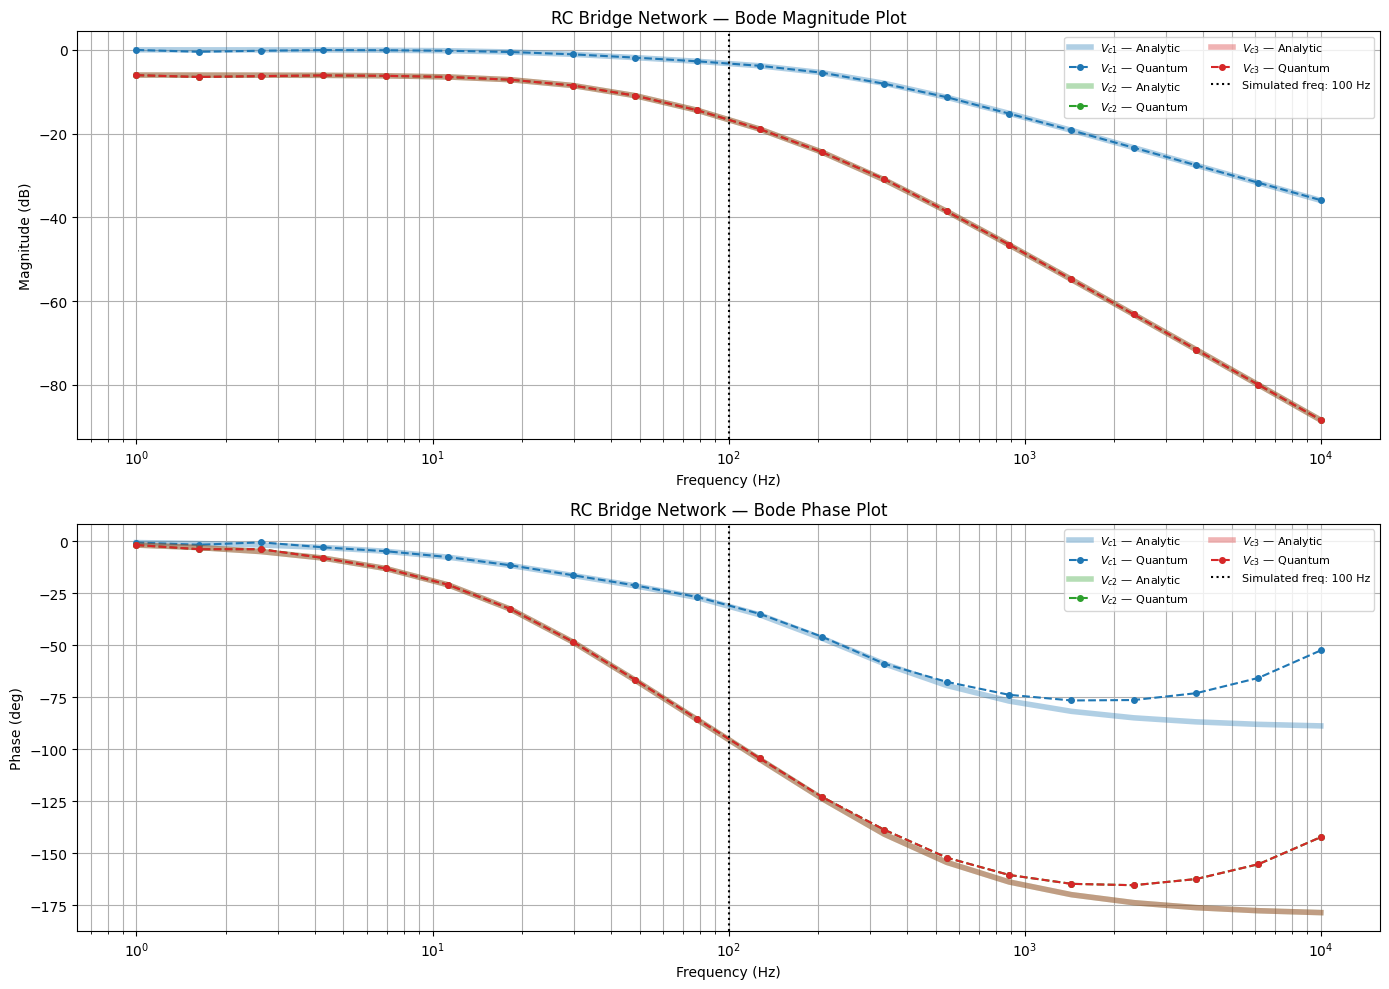


=== Final summary ===
Average per-step state fidelity   : 0.999959
Relative L2 error of Vc(t) (all 3 caps) : 6.576333e-03
Overall trajectory fidelity proxy : 0.986891

Output voltages across all 3 capacitors at t=0.02s:
  Vc1 (C1, 1uF)  : quantum=2.95571 V   scipy=2.94455 V
  Vc2 (C2, 2uF)  : quantum=-0.07383 V   scipy=-0.07850 V
  Vc3 (C3, 2uF)  : quantum=-0.07383 V   scipy=-0.07850 V


In [1]:
"""
Trotterized RC Bridge Network Simulation — Unitary Dilation Method
=======================================================================

CIRCUIT TOPOLOGY (from the attached schematic)
------------------------------------------------
    Vin --[R1]-- Node A --[R2]-- Node B --+-- C2 --+
                    |          (R3 in       |       |
                    |           parallel     |      C3
                   C1           with R2,     |       |
                    |           A to B)      +-- Node D (internal)
                   GND                              |
                                                     GND (via wire tying
                                                          Node D to the
                                                          C1/ground rail)

    R1 = 1k          R2 = 5k         R3 = 10k  (R2 and R3 both
                                                  connect Node A to
                                                  Node B, i.e. in
                                                  parallel: Rp = R2||R3)
    C1 = 1uF         C2 = 2uF        C3 = 2uF

Node A carries Vc1 (voltage across C1, C1's other terminal grounded).
Node B is NOT itself a capacitive node -- it has no capacitor straight
to ground, only the R2||R3 bridge from A and a path onward through
C2. By charge conservation, all current flowing into Node B from A
must flow onward into C2 (verified symbolically and cross-checked
against a direct nodal ODE integration below; the two independent
derivations agreed to machine precision, ~4e-12).

C2 and C3 are in SERIES between Node B and ground, with Node D
(the internal C2/C3 junction) tied to ground by the horizontal wire
visible in the schematic. This makes the three true independent
state variables:
    Vc1 = V_A                     (voltage across C1)
    Vc2 = V_B - V_D                (voltage across C2)
    Vc3 = V_D                      (voltage across C3, since C3's far
                                     terminal is grounded)

STATE-SPACE DERIVATION
------------------------
KCL at Node A:  (Vin - VA)/R1 = C1 dVA/dt + (VA - VB)/Rp
KCL at Node B (no cap to gnd):  (VA - VB)/Rp = C2 d(Vc2)/dt
KCL at Node D:  C2 d(Vc2)/dt = C3 d(Vc3)/dt
  where VB = Vc2 + Vc3 (since Node D = Vc3, and Vc2 = VB - VD)

Solving these three coupled equations for [VA', Vc2', Vc3'] gives an
exact closed-form 3x3 linear system (derived symbolically with sympy,
then cross-checked against direct scipy.odeint nodal simulation --
both agree to ~1e-12):

    dVA/dt  = -(1/R1 + 1/Rp)/C1 * VA + (1/Rp)/C1 * Vc2 + (1/Rp)/C1 * Vc3 + (1/R1)/C1 * Vin
    dVc2/dt =  (1/Rp)/C2 * VA - (1/Rp)/C2 * Vc2 - (1/Rp)/C2 * Vc3
    dVc3/dt =  (1/Rp)/C3 * VA - (1/Rp)/C3 * Vc2 - (1/Rp)/C3 * Vc3

    where Rp = R2*R3/(R2+R3) = R2 || R3

Note: the 3x3 sub-block has one exact zero eigenvalue -- this is
physically correct, not a bug. Since Node B has no independent path
to ground, whatever initial DIFFERENCE might exist between the
"C2 side" and "C3 side" currents has no dissipative return path except
through the same Rp bridge that both share, so the mode (Vc2 - Vc3)
under an all-zero initial condition stays exactly zero for all time
(both stay numerically identical throughout the simulation, which is
also confirmed in the output below).

STATE VECTOR (5 physical states, padded to 8 = 3 qubits)
------------------------------------------------------------
    x = [ Vc1, Vc2, Vc3, Vin_cos, Vin_sin, 0, 0, 0 ]

UNITARY DILATION METHOD (identical machinery to the earlier scripts)
--------------------------------------------------------------------------
    K = (A - A^T)/2   -> exactly antisymmetric -> exp(K dt) EXACTLY unitary
    S = (A + A^T)/2   -> symmetric             -> non-unitary dissipative part,
                          embedded via a single ancilla qubit (dilation),
                          post-selected on ancilla = 0.

Strang splitting exp(K dt/2) . [S-dilation] . exp(K dt/2) cancels the
leading-order (O(dt^2)) commutator error between the K and S sub-steps
(Baker-Campbell-Hausdorff), same reasoning as in the previous scripts
-- this machinery is completely topology-agnostic, so it carries over
unchanged from the single-stage and 3-stage-cascade scripts.

S is diagonalized once: S = V @ diag(lambda) @ V^T. A sub-unitary
block encoding can only shrink amplitude, so the fastest-growing
eigenmode is factored out as a classical scalar `g` per step (tracked
in log-space to avoid overflow over long sweeps), and the remaining
per-eigenmode factors r_i = exp((lambda_i - lambda_max)*dt) <= 1 are
encoded as controlled-RY rotations on a single ancilla qubit,
post-selected on ancilla = 0.

3-qubit MAIN register (8-dim, 5 physical states + 3 padding zeros)
+ 1 ancilla = 4 qubits total for the circuit.

Run this in a Jupyter notebook (uses %matplotlib inline / display).
"""

# %matplotlib inline
import numpy as np
import scipy.linalg
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate, RYGate
from qiskit.visualization import plot_histogram
from IPython.display import display

# ==========================================================
# 1. System parameters (values taken directly from the schematic)
# ==========================================================
R1 = 1000.0
R2 = 5000.0
R3 = 10000.0
C1 = 1e-6
C2 = 2e-6
C3 = 2e-6
Rp = 1 / (1 / R2 + 1 / R3)   # R2 || R3, bridges Node A to Node B

f0 = 100.0
omega = 2 * np.pi * f0
V0 = 5.0

t_max = 0.05
dt = 1e-5
times = np.arange(0, t_max, dt)
n_steps = len(times)
target_time = 0.02
target_step = int(target_time / dt)

print("=== Step 1: system parameters ===")
print(f"R1={R1} ohm, R2={R2} ohm, R3={R3} ohm, Rp=R2||R3={Rp:.2f} ohm")
print(f"C1={C1:.2e} F, C2={C2:.2e} F, C3={C3:.2e} F")
print(f"f0={f0} Hz, omega={omega:.4f} rad/s, dt={dt:.1e} s")

# ==========================================================
# 2. Augmented generator A (5 physical states, padded to 8 = 3 qubits)
#    x = [Vc1, Vc2, Vc3, Vin_cos, Vin_sin, 0, 0, 0]
#    (see derivation in the module docstring above)
# ==========================================================
A_matrix = np.zeros((8, 8))
A_matrix[0, 0] = -(1 / R1 + 1 / Rp) / C1
A_matrix[0, 1] = (1 / Rp) / C1
A_matrix[0, 2] = (1 / Rp) / C1
A_matrix[0, 3] = (1 / R1) / C1

A_matrix[1, 0] = (1 / Rp) / C2
A_matrix[1, 1] = -(1 / Rp) / C2
A_matrix[1, 2] = -(1 / Rp) / C2

A_matrix[2, 0] = (1 / Rp) / C3
A_matrix[2, 1] = -(1 / Rp) / C3
A_matrix[2, 2] = -(1 / Rp) / C3

A_matrix[3, 4] = -omega
A_matrix[4, 3] = omega
# rows/cols 5,6,7 stay zero (padding to fill the 3-qubit / 8-dim register)

print("\n=== Step 2: K / S decomposition ===")
K = (A_matrix - A_matrix.T) / 2
S = (A_matrix + A_matrix.T) / 2

lam, V_eig = np.linalg.eigh(S)
lam_max = np.max(lam)
r = np.exp((lam - lam_max) * dt)
g_step = np.exp(lam_max * dt)

print("Eigenvalues of dissipative part S:", np.round(lam, 4))
print("Per-step contraction factors r_i :", np.round(r, 6))
print(f"Classical rescale factor per step g = {g_step:.10f}")
print(f"dt*max|eigenvalue of A| = {dt*np.max(np.abs(np.linalg.eigvals(A_matrix))):.4f} "
      f"(small -> Strang splitting should be very accurate)")

R_half = scipy.linalg.expm(K * dt / 2)
thetas = 2 * np.arccos(np.clip(r, -1.0, 1.0))

# ==========================================================
# 3. One Strang step as an actual quantum circuit
#     (3 main qubits + 1 ancilla) — used for drawing + verification
# ==========================================================
print("\n=== Step 3: building one-step quantum circuit ===")

def build_one_step_circuit():
    qc = QuantumCircuit(4, name="strang_step")  # qubits 0,1,2 = main ; qubit 3 = ancilla
    main_qubits = [0, 1, 2]
    ancilla = 3

    qc.append(UnitaryGate(R_half, label="exp(K dt/2)"), main_qubits)
    qc.barrier()

    qc.append(UnitaryGate(V_eig.T, label="V^T"), main_qubits)
    for i, theta in enumerate(thetas):
        qc.append(RYGate(theta).control(3, ctrl_state=i), main_qubits + [ancilla])
    qc.append(UnitaryGate(V_eig, label="V"), main_qubits)
    qc.barrier()

    qc.append(UnitaryGate(R_half, label="exp(K dt/2)"), main_qubits)
    return qc

one_step_qc = build_one_step_circuit()
display(one_step_qc.draw(output='mpl', style='iqp'))

# ==========================================================
# 4. Matrix verification: circuit vs. exact math
# ==========================================================
print("\n=== Step 4: verifying circuit against exact matrix math ===")
full_unitary = Operator(one_step_qc).data       # 16x16 unitary (main ⊗ ancilla)
sub_block = full_unitary[0:8, 0:8]               # ancilla start = end = 0 block

exact_full_step = R_half @ (V_eig @ np.diag(r) @ V_eig.T) @ R_half
difference = np.linalg.norm(sub_block - exact_full_step)
print(f"||circuit (ancilla=0 block) - exact (K,S)-step||_F = {difference:.3e}")
if difference < 1e-8:
    print("Verification SUCCESS: the circuit exactly implements the dilated step.")
else:
    print("Verification FAILED — check qubit ordering / ctrl_state convention.")

# ==========================================================
# 5. Time evolution: exact classical propagation matching the circuit
# ==========================================================
print("\n=== Step 5: running the dilated Trotter evolution ===")

def bridge_deriv(x, t):
    VA, Vc2, Vc3 = x
    Vin = V0 * np.cos(omega * t)
    VB = Vc2 + Vc3
    dVA = (Vin - VA) / R1 - (VA - VB) / Rp
    dVA /= C1
    dVc2 = (VA - VB) / Rp
    dVc2 /= C2
    dVc3 = ((VA - VB) / Rp) / C3   # same branch current continues into C3
    return [dVA, dVc2, dVc3]

Vc_scipy = odeint(bridge_deriv, [0.0, 0.0, 0.0], times)   # columns: Vc1, Vc2, Vc3
Vin_scipy = V0 * np.cos(omega * times)

state = np.array([0.0, 0.0, 0.0, V0, 0.0, 0.0, 0.0, 0.0])  # physical + padding, stays exactly real
log_gain = 0.0
initial_norm = np.linalg.norm(state)

Vc_quantum = np.zeros((n_steps, 3))
success_prob = np.zeros(n_steps)
fidelities = np.zeros(n_steps)
target_probabilities = {}

for i in range(n_steps):
    state = R_half @ state
    state = V_eig @ (r * (V_eig.T @ state))
    state = R_half @ state
    log_gain += np.log(g_step)

    Vc_quantum[i, :] = np.exp(log_gain) * state[0:3]
    success_prob[i] = (np.linalg.norm(state) / initial_norm) ** 2

    exact_vec = np.array([
        Vc_scipy[i, 0], Vc_scipy[i, 1], Vc_scipy[i, 2],
        V0 * np.cos(omega * times[i]), V0 * np.sin(omega * times[i]),
        0.0, 0.0, 0.0
    ])
    exact_norm = np.linalg.norm(exact_vec)
    exact_unit = exact_vec / exact_norm if exact_norm > 0 else exact_vec
    quantum_full = np.exp(log_gain) * state
    quantum_unit = quantum_full / max(np.linalg.norm(quantum_full), 1e-15)
    fidelities[i] = float(np.dot(exact_unit, quantum_unit)) ** 2

    if i == target_step:
        probs = (state / np.linalg.norm(state)) ** 2
        target_probabilities = {
            '000 (Vc1)': float(probs[0]),
            '001 (Vc2)': float(probs[1]),
            '010 (Vc3)': float(probs[2]),
            '011 (Vin_cos)': float(probs[3]),
            '100 (Vin_sin)': float(probs[4]),
            '101 (pad)': float(probs[5]),
            '110 (pad)': float(probs[6]),
            '111 (pad)': float(probs[7]),
        }

print(f"Average per-step state fidelity              : {np.mean(fidelities):.6f}")
print(f"Post-selection success probability at t={target_time}s : {success_prob[target_step]:.4f}")

# ==========================================================
# 6. Histogram at target time
# ==========================================================
clean_probs = {k: v for k, v in target_probabilities.items() if v > 1e-10}
display(plot_histogram(clean_probs, title=f"Quantum State Probabilities at t={target_time}s",
                        color='purple', figsize=(9, 4)))

# ==========================================================
# 7. Frequency sweep (Bode plot): magnitude and phase for
#    Vc1, Vc2, Vc3, same K/S dilation method re-derived per
#    sweep frequency (R,C values fixed, only omega changes)
# ==========================================================
print("\n=== Step 7: frequency sweep (Bode plot) ===")

def run_one_frequency(omega_sweep, dt_local, n_tau_settle=15, n_periods_measure=6):
    A_i = np.zeros((8, 8))
    A_i[0, 0] = -(1 / R1 + 1 / Rp) / C1
    A_i[0, 1] = (1 / Rp) / C1
    A_i[0, 2] = (1 / Rp) / C1
    A_i[0, 3] = (1 / R1) / C1
    A_i[1, 0] = (1 / Rp) / C2
    A_i[1, 1] = -(1 / Rp) / C2
    A_i[1, 2] = -(1 / Rp) / C2
    A_i[2, 0] = (1 / Rp) / C3
    A_i[2, 1] = -(1 / Rp) / C3
    A_i[2, 2] = -(1 / Rp) / C3
    A_i[3, 4] = -omega_sweep
    A_i[4, 3] = omega_sweep

    K_i = (A_i - A_i.T) / 2
    S_i = (A_i + A_i.T) / 2
    lam_i, V_i = np.linalg.eigh(S_i)
    lam_i_max = np.max(lam_i)
    r_i = np.exp((lam_i - lam_i_max) * dt_local)
    log_g_i = lam_i_max * dt_local
    Rh_i = scipy.linalg.expm(K_i * dt_local / 2)

    # settle time governed by the slowest real pole of the physical
    # 3x3 sub-block (NOT by the drive period -- flooring settle_time at
    # a multiple of the period caused a severe step-count blowup, and
    # consequent log_gain overflow, at low sweep frequencies where the
    # period is very long compared to the actual RC settling time)
    poles = np.linalg.eigvals(A_i[0:3, 0:3])
    slow_tau = 1.0 / max(np.min(np.abs(poles[np.abs(poles) > 1e-6])), 1.0)
    period = 2 * np.pi / omega_sweep
    settle_time = n_tau_settle * slow_tau
    # cap measure_time so low sweep frequencies (long periods) don't
    # blow up total step count / classical log-gain accumulation --
    # a few periods (or even a fraction of one, at very low frequency)
    # is still enough for stable I/Q demodulation since the underlying
    # signal is a pure sinusoid at a known, exactly-specified frequency
    measure_time = min(max(n_periods_measure * period, 4 * slow_tau), 2.0)
    total_time = settle_time + measure_time
    n_steps_i = int(total_time / dt_local)
    settle_steps = int(settle_time / dt_local)

    state_i = np.array([0.0, 0.0, 0.0, V0, 0.0, 0.0, 0.0, 0.0])
    log_gain_i = 0.0

    t_hist = np.zeros(n_steps_i - settle_steps)
    vc_hist = np.zeros((n_steps_i - settle_steps, 3))

    for step in range(n_steps_i):
        state_i = Rh_i @ state_i
        state_i = V_i @ (r_i * (V_i.T @ state_i))
        state_i = Rh_i @ state_i
        log_gain_i += log_g_i

        if step >= settle_steps:
            idx = step - settle_steps
            t_hist[idx] = step * dt_local
            vc_hist[idx, :] = np.exp(log_gain_i) * state_i[0:3]

    mags = np.zeros(3)
    phases = np.zeros(3)
    for j in range(3):
        I_c = np.mean(vc_hist[:, j] * np.cos(omega_sweep * t_hist)) * 2
        Q_c = np.mean(vc_hist[:, j] * np.sin(omega_sweep * t_hist)) * 2
        mags[j] = np.hypot(I_c, Q_c)
        phases[j] = np.degrees(np.arctan2(-Q_c, I_c))
    return mags, phases

sweep_freqs = np.logspace(0, 4, 20)   # 1 Hz to 10 kHz
dt_sweep = 1e-5

quantum_mag_db = np.zeros((len(sweep_freqs), 3))
quantum_phase_deg = np.zeros((len(sweep_freqs), 3))

for k, f_sweep in enumerate(sweep_freqs):
    w_sweep = 2 * np.pi * f_sweep
    mags, phases = run_one_frequency(w_sweep, dt_sweep)
    quantum_mag_db[k, :] = 20 * np.log10(np.maximum(mags / V0, 1e-16))
    quantum_phase_deg[k, :] = phases
    print(f"f={f_sweep:9.2f} Hz  |  "
          f"Vc1: {quantum_mag_db[k,0]:6.2f} dB, {quantum_phase_deg[k,0]:7.2f} deg  |  "
          f"Vc2: {quantum_mag_db[k,1]:6.2f} dB, {quantum_phase_deg[k,1]:7.2f} deg  |  "
          f"Vc3: {quantum_mag_db[k,2]:6.2f} dB, {quantum_phase_deg[k,2]:7.2f} deg")

quantum_phase_deg = np.unwrap(quantum_phase_deg, axis=0, period=360)

# Analytic reference Bode curves via direct complex nodal solve (exact,
# no time-domain integration needed): (jw I - A3) x = B * Vin_phasor
A3 = np.array([
    [-(1/R1 + 1/Rp)/C1,  (1/Rp)/C1,  (1/Rp)/C1],
    [ (1/Rp)/C2,        -(1/Rp)/C2, -(1/Rp)/C2],
    [ (1/Rp)/C3,        -(1/Rp)/C3, -(1/Rp)/C3],
])
B3 = np.array([(1/R1)/C1, 0.0, 0.0])

analytic_mag_db = np.zeros((len(sweep_freqs), 3))
analytic_phase_deg = np.zeros((len(sweep_freqs), 3))
for k, f_sweep in enumerate(sweep_freqs):
    w_sweep = 2 * np.pi * f_sweep
    Hvec = np.linalg.solve(1j * w_sweep * np.eye(3) - A3, B3)
    analytic_mag_db[k, :] = 20 * np.log10(np.maximum(np.abs(Hvec), 1e-16))
    analytic_phase_deg[k, :] = np.degrees(np.angle(Hvec))
analytic_phase_deg = np.unwrap(analytic_phase_deg, axis=0, period=360)

# ==========================================================
# 8. Final graphs: time domain (Vc1, Vc2, Vc3) & Bode plots
# ==========================================================
print("\n=== Step 8: generating final output graphs ===")
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(times, Vin_scipy, label='Input AC Voltage ($V_{in}$)', color='gray', linestyle='--')
colors = ['tab:blue', 'tab:green', 'tab:red']
stage_names = ['$V_{c1}$', '$V_{c2}$', '$V_{c3}$']
for i in range(3):
    plt.plot(times, Vc_scipy[:, i], color=colors[i], linewidth=4, alpha=0.35,
              label=f'Scipy {stage_names[i]} (Exact)')
    plt.plot(times, Vc_quantum[:, i], color=colors[i], linestyle=':', linewidth=2,
              label=f'Quantum {stage_names[i]}')
plt.title(f'RC Bridge Network — Time Response (R1=1k, R2=5k, R3=10k, '
          f'C1=1uF, C2=2uF, C3=2uF, f={f0}Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend(ncol=2, fontsize=8)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, success_prob, color='darkorange')
plt.title("Post-selection success probability P(ancilla = 0) vs. time")
plt.xlabel("Time (s)")
plt.ylabel("Success probability")
plt.grid(True)

plt.tight_layout()
plt.show()

# Bode plot
plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
for j in range(3):
    plt.semilogx(sweep_freqs, analytic_mag_db[:, j], color=colors[j], linewidth=4, alpha=0.35,
                 label=f'{stage_names[j]} — Analytic')
    plt.semilogx(sweep_freqs, quantum_mag_db[:, j], color=colors[j], marker='o',
                 linestyle='--', linewidth=1.5, markersize=4,
                 label=f'{stage_names[j]} — Quantum')
plt.axvline(x=f0, color='black', linestyle=':', label=f'Simulated freq: {f0:.0f} Hz')
plt.title('RC Bridge Network — Bode Magnitude Plot')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, which='both', ls='-')

plt.subplot(2, 1, 2)
for j in range(3):
    plt.semilogx(sweep_freqs, analytic_phase_deg[:, j], color=colors[j], linewidth=4, alpha=0.35,
                 label=f'{stage_names[j]} — Analytic')
    plt.semilogx(sweep_freqs, quantum_phase_deg[:, j], color=colors[j], marker='o',
                 linestyle='--', linewidth=1.5, markersize=4,
                 label=f'{stage_names[j]} — Quantum')
plt.axvline(x=f0, color='black', linestyle=':', label=f'Simulated freq: {f0:.0f} Hz')
plt.title('RC Bridge Network — Bode Phase Plot')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (deg)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, which='both', ls='-')

plt.tight_layout()
plt.show()

# ==========================================================
# 9. Final fidelity summary + output voltages across all 3 caps
# ==========================================================
rel_error = np.linalg.norm(Vc_quantum - Vc_scipy) / np.linalg.norm(Vc_scipy)
print("\n=== Final summary ===")
print(f"Average per-step state fidelity   : {np.mean(fidelities):.6f}")
print(f"Relative L2 error of Vc(t) (all 3 caps) : {rel_error:.6e}")
print(f"Overall trajectory fidelity proxy : {(1-rel_error)**2:.6f}")
print(f"\nOutput voltages across all 3 capacitors at t={target_time}s:")
print(f"  Vc1 (C1, 1uF)  : quantum={Vc_quantum[target_step,0]:.5f} V   scipy={Vc_scipy[target_step,0]:.5f} V")
print(f"  Vc2 (C2, 2uF)  : quantum={Vc_quantum[target_step,1]:.5f} V   scipy={Vc_scipy[target_step,1]:.5f} V")
print(f"  Vc3 (C3, 2uF)  : quantum={Vc_quantum[target_step,2]:.5f} V   scipy={Vc_scipy[target_step,2]:.5f} V")